Algorithm code

C:\Users\HP\AppData\Local\Temp\ipykernel_35792\2751119953.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


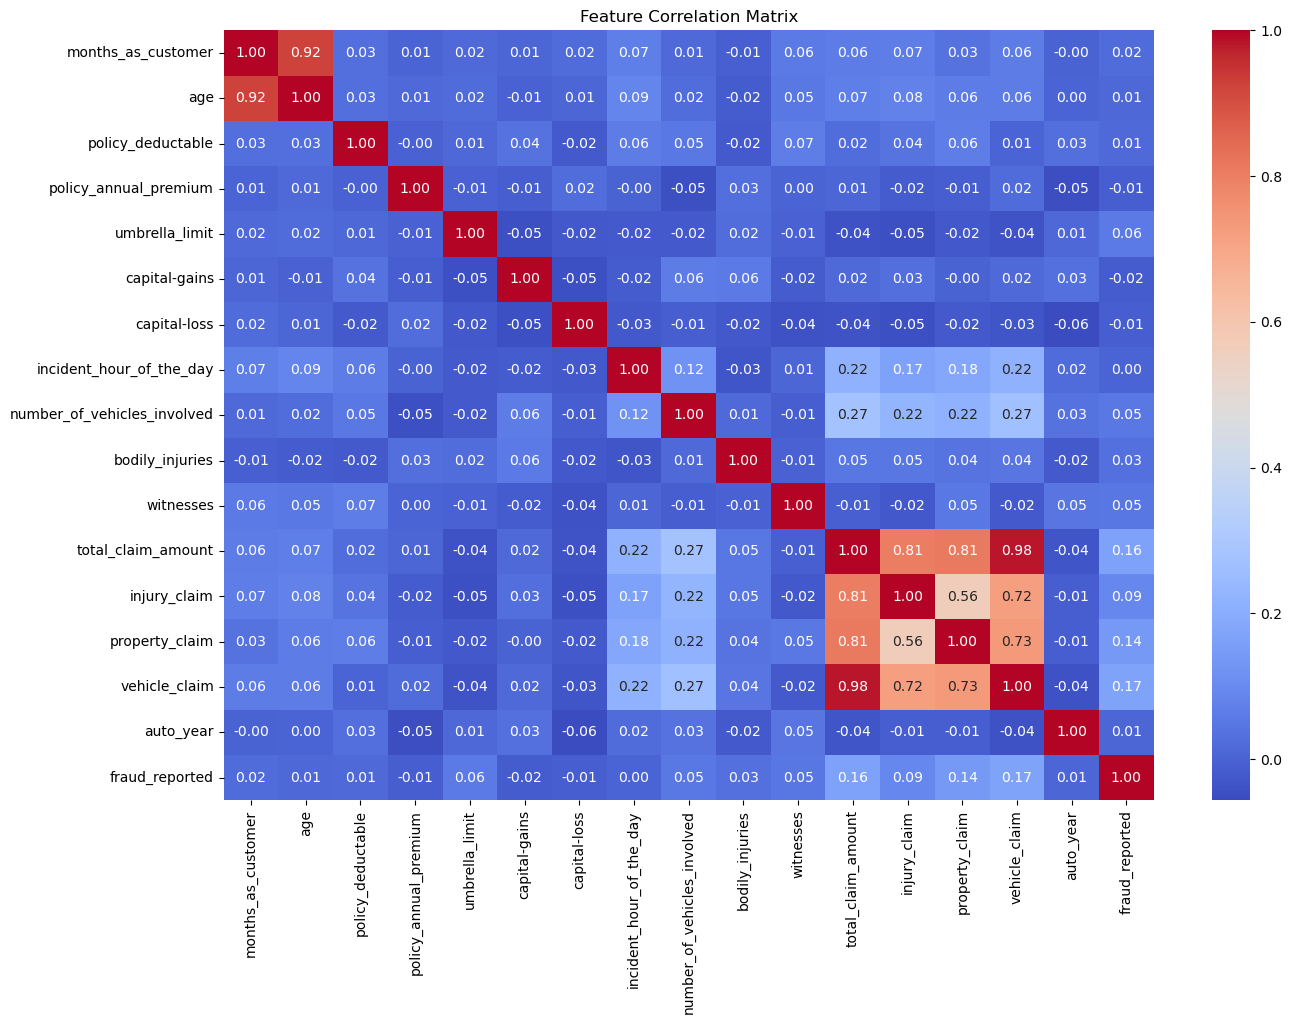

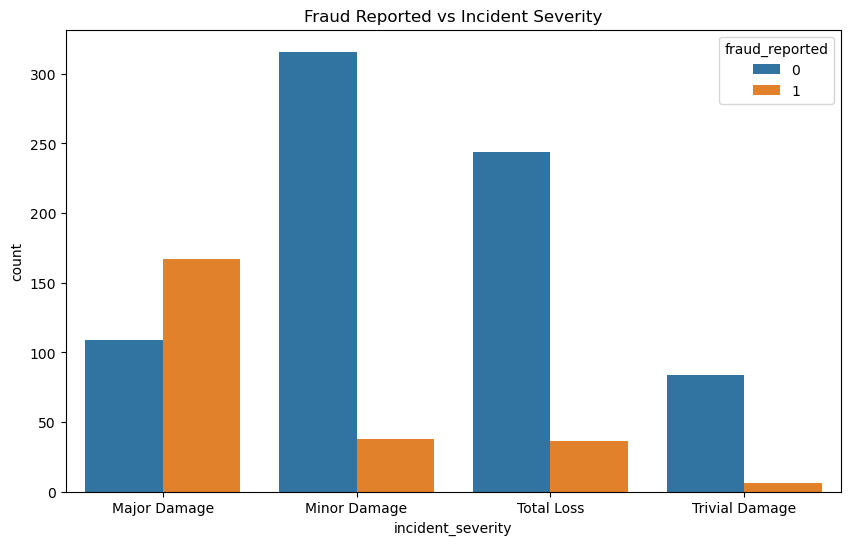

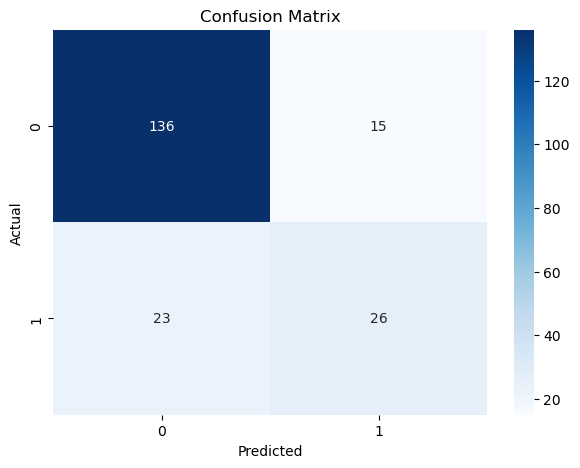

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88       151
           1       0.63      0.53      0.58        49

    accuracy                           0.81       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.80      0.81      0.80       200



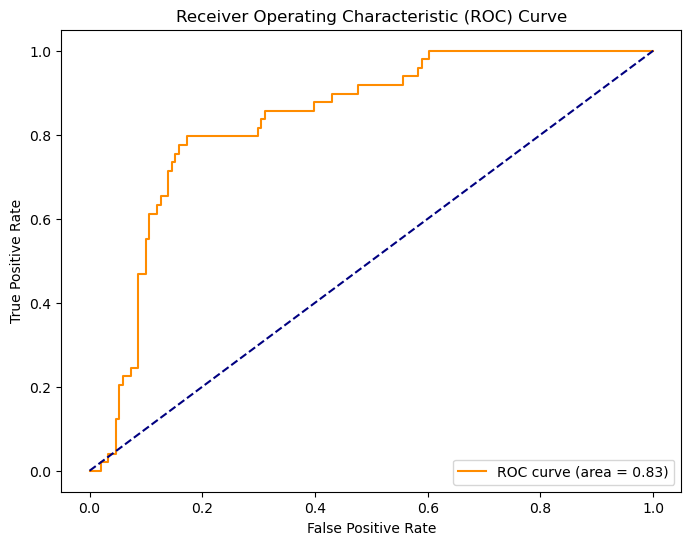

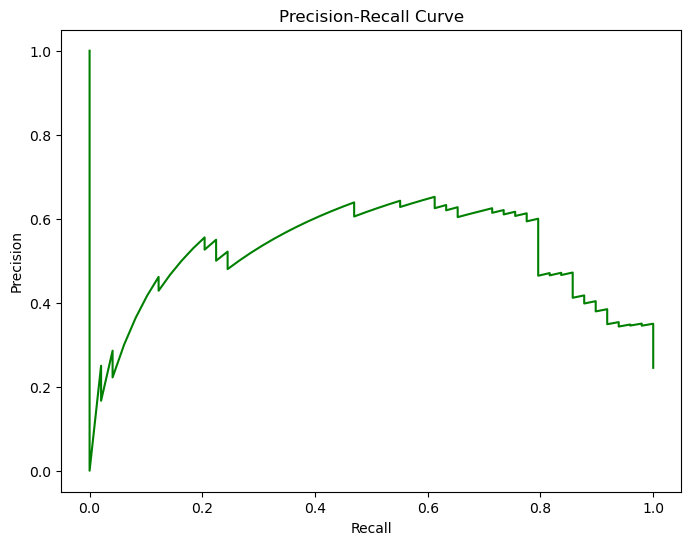

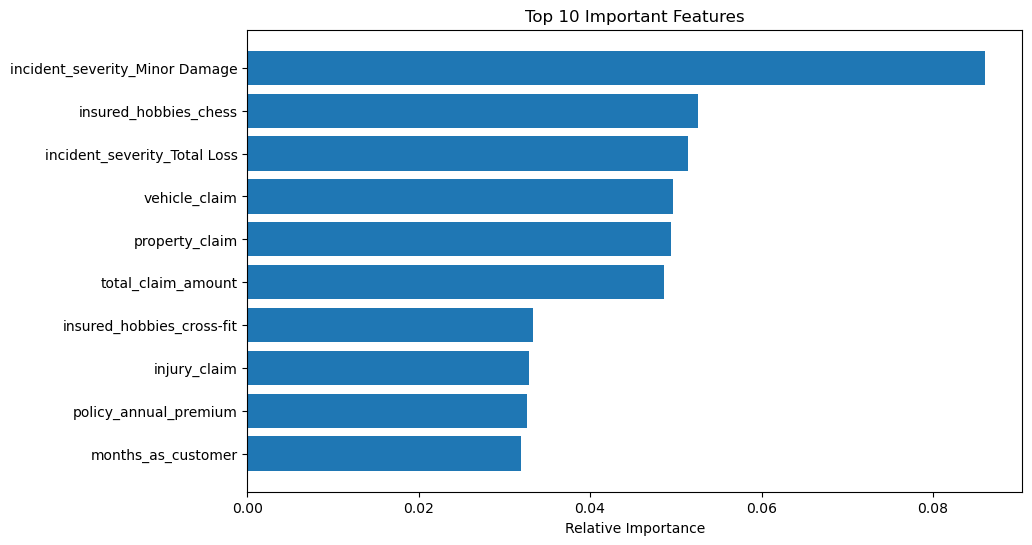

Files 'fraud_model.pkl' and 'model_columns.pkl' have been generated.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, precision_recall_curve
)

# ==========================================
# Epic 2: Data Collection & Preparation
# ==========================================
df = pd.read_csv("C:\\Users\\HP\\Downloads\\insurance_claims.csv")

# Handling Missing Values (The dataset uses '?' for missing data)
df.replace('?', np.nan, inplace=True)

# Dropping unnecessary or high-cardinality columns
cols_to_drop = ['policy_number', 'policy_bind_date', 'insured_zip',
                'incident_location', 'incident_date', '_c39']
df.drop(columns=cols_to_drop, inplace=True)

# Filling missing values with mode
for col in ['collision_type', 'property_damage', 'police_report_available']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encoding the target variable (fraud_reported)
df['fraud_reported'] = df['fraud_reported'].map({'Y': 1, 'N': 0})

# ==========================================
# Epic 3: Exploratory Data Analysis (EDA)
# ==========================================

# 1. Correlation Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()



# 2. Fraud Distribution by Incident Severity
plt.figure(figsize=(10, 6))
sns.countplot(x='incident_severity', hue='fraud_reported', data=df)
plt.title('Fraud Reported vs Incident Severity')
plt.show()

# ==========================================
# Epic 4 & 5: Model Building & Performance Testing
# ==========================================

# Feature Engineering: One-Hot Encoding for categorical features
cat_cols = df.select_dtypes(include=['object']).columns
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Train-Test Split
X = df_final.drop('fraud_reported', axis=1)
y = df_final['fraud_reported']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model Training: Random Forest with Hyperparameter Tuning
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'class_weight': ['balanced']
}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

# --- PERFORMANCE METRICS ---

# 1. Confusion Matrix
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



# 2. Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# 3. ROC Curve and AUC
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



# 4. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()



# 5. Feature Importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Important Features')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# ==========================================
# Epic 6: Model Deployment Preparation
# ==========================================

# Saving the model and columns for the web app
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Files 'fraud_model.pkl' and 'model_columns.pkl' have been generated.")